# Stability Analysis — RQ2

Measures whether feature attribution rankings are consistent across experimental splits.
Three split types are evaluated:
- **§13 Temporal** — early vs late observation window
- **§14 Route subgroups** — top departure→destination pairs by volume
- **§15 Cross-offer** — L5B15 vs CLUG replication variant

For each split pair and explanation method (DT / SHAP / LIME), rankings are computed
independently on each sub-split and compared with Spearman ρ, Jaccard@5, and Jaccard@10.

**Run `05_surrogate_fit.ipynb` and `06_explanation.ipynb` for each variant first.**

In [1]:
# ── Config ────────────────────────────────────────────────────────────────
from pathlib import Path

PRIMARY_VARIANT      = "L5B15"
REPLICATION_VARIANTS = ["CLUG", "BookingDotCom", "Cartrawler"]   # add variants here as notebooks 05+06 are run for them

PROCESSED_DIR = Path("../data/processed")
ARTIFACT_DIR  = Path("../data/artifacts")
ADM_BINNING   = Path("../data/adm/data-Predictor-binning-snapshot.json")

LIME_SAMPLE    = 500   # instances sampled per split for LIME (feasibility)
LIME_N_SAMPLES = 200   # perturbations per LIME instance
MIN_ROUTE_OBS  = 400   # minimum observations to include a route subgroup (lowered
                       # from 500 after the modelTechnique=="0.0" filter halved
                       # row counts; the top-4 L5B15 routes have 425–505 obs each)
TOP_N_ROUTES   = 4     # number of top routes to analyse
TEMPORAL_SPLIT = "2026-04-27"   # median pxDecisionTime for L5B15

print(f"Primary variant : {PRIMARY_VARIANT}")
print(f"Replication     : {REPLICATION_VARIANTS}")
print(f"Temporal split  : {TEMPORAL_SPLIT}")

Primary variant : L5B15
Replication     : ['CLUG', 'BookingDotCom', 'Cartrawler']
Temporal split  : 2026-04-27


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

sys.path.insert(0, "../src")
from my_project.explanation import (
    PegaBinEncoder,
    compute_split_rankings,
)
from my_project.features import PEGA_MODEL_IDS, VARIANT_FEATURES
from my_project.metrics import feature_ranking, jaccard_at_k, stability_row, stability_spearman
from my_project.parsing import load_pega_bins
from my_project.surrogate import build_feature_matrix

print("Imports OK")

Imports OK


In [3]:
# ── Load full dataset and primary variant artifacts ────────────────────────
import json as _json
import pandas as _pd

_lug = _pd.read_parquet(PROCESSED_DIR / "luggage_email_outbound.parquet")
_tp_path = PROCESSED_DIR / "thirdparty_email_outbound.parquet"
df_raw = _pd.concat(
    [_lug, _pd.read_parquet(_tp_path)] if _tp_path.exists() else [_lug],
    ignore_index=True,
)
del _lug, _pd, _tp_path

# Restrict to the production-decision technique (label "0.0"). Every scoring
# event is evaluated by two parallel techniques; analysis is on the model
# that actually drives offer decisions, matching what 05_surrogate_fit
# fitted. See 03_eda §6.10.
df_raw = df_raw[df_raw["modelTechnique"] == "0.0"].reset_index(drop=True)

df_raw["pxDecisionTime"] = pd.to_datetime(df_raw["pxDecisionTime"], utc=True, errors="coerce")

df = df_raw[df_raw["pyName"] == PRIMARY_VARIANT].reset_index(drop=True)

cfg = VARIANT_FEATURES[PRIMARY_VARIANT]

# Use the EXACT training feature set + order saved by 05_surrogate_fit, not
# cfg.features. 05 drops features that are constant in the variant's slice;
# loading via cfg.features would add the dropped column back at the wrong
# position, misaligning the saved model's cat_feature_indices.
saved_feature_cols = _json.loads(
    (ARTIFACT_DIR / PRIMARY_VARIANT / "feature_cols.json").read_text()
)
X, y, cat_cols, num_cols = build_feature_matrix(df, saved_feature_cols, cfg.numeric)

# Metadata aligned with X (same row order as df)
meta = df[["pxDecisionTime",
           "CustBookedFlight.FlightData.DepartureAirport",
           "CustBookedFlight.FlightData.DestinationAirport"]].copy()
meta["route"] = meta["CustBookedFlight.FlightData.DepartureAirport"].astype(str) \
              + "->" \
              + meta["CustBookedFlight.FlightData.DestinationAirport"].astype(str)

# Global CatBoost surrogate
cb_model = CatBoostRegressor()
cb_model.load_model(str(ARTIFACT_DIR / PRIMARY_VARIANT / "catboost_model.cbm"))

# Background data for LIME (original train split)
train_idx  = np.load(ARTIFACT_DIR / PRIMARY_VARIANT / "train_idx.npy")
X_background = X.iloc[train_idx]

# Pega bin encoder for DT (loaded once, reused across all splits)
print("Loading Pega bins...")
pega_bins = load_pega_bins(ADM_BINNING, PEGA_MODEL_IDS[PRIMARY_VARIANT])
pega_enc  = PegaBinEncoder(pega_bins, cat_cols)
print(f"Pega bins loaded for {len(pega_bins)} predictors")

print(f"\nDataset: {len(df):,} rows  |  {X.shape[1]} features")
print(f"Date range: {meta['pxDecisionTime'].min().date()} → {meta['pxDecisionTime'].max().date()}")

Loading Pega bins...


Pega bins loaded for 147 predictors

Dataset: 31,709 rows  |  23 features
Date range: 2026-03-26 → 2026-04-30


## §13 Temporal Split Stability

The observation window is divided at the median `pxDecisionTime` into an early and late period.
Explanation rankings are computed independently on each half and compared.

In [4]:
split_date = pd.Timestamp(TEMPORAL_SPLIT, tz="UTC")

mask_early = meta["pxDecisionTime"] <= split_date
mask_late  = meta["pxDecisionTime"] >  split_date

X_early, y_early = X[mask_early], y[mask_early]
X_late,  y_late  = X[mask_late],  y[mask_late]

print(f"Temporal split at {TEMPORAL_SPLIT}")
print(f"  Early : {len(X_early):,} rows  "
      f"({meta.loc[mask_early, 'pxDecisionTime'].min().date()} → "
      f"{meta.loc[mask_early, 'pxDecisionTime'].max().date()})")
print(f"  Late  : {len(X_late):,} rows  "
      f"({meta.loc[mask_late, 'pxDecisionTime'].min().date()} → "
      f"{meta.loc[mask_late, 'pxDecisionTime'].max().date()})")

Temporal split at 2026-04-27
  Early : 15,198 rows  (2026-03-26 → 2026-04-26)
  Late  : 16,511 rows  (2026-04-27 → 2026-04-30)


In [5]:
print("Computing rankings for early split...")
rankings_early = compute_split_rankings(
    X_early, y_early, cb_model, X_background, cat_cols, num_cols, pega_enc,
    lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
)
print("Computing rankings for late split...")
rankings_late = compute_split_rankings(
    X_late, y_late, cb_model, X_background, cat_cols, num_cols, pega_enc,
    lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
)
print("Done.")

Computing rankings for early split...


Computing rankings for late split...


Done.


Temporal split stability:


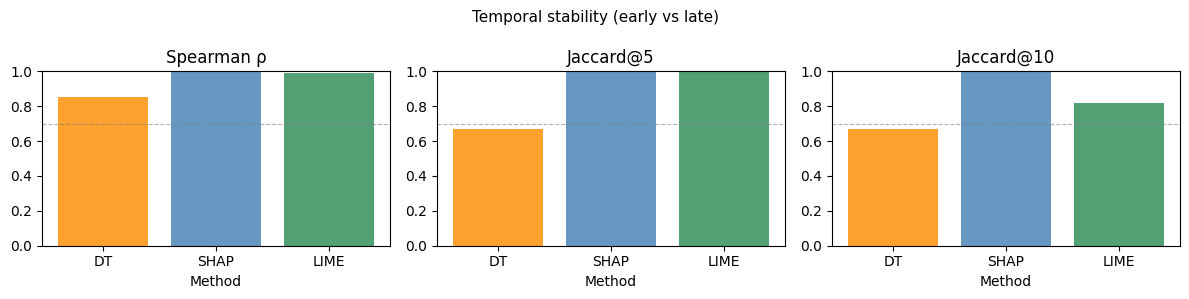

In [6]:
shared = list(X.columns)
temporal_rows = stability_row(
    rankings_early, rankings_late,
    label_a="early", label_b="late",
    n_a=len(X_early), n_b=len(X_late),
    shared_features=shared,
)
temporal_df = pd.DataFrame(temporal_rows)

print("Temporal split stability:")
display(
    temporal_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ax, metric in zip(axes, ["Spearman ρ", "Jaccard@5", "Jaccard@10"]):
    ax.bar(temporal_df["method"], temporal_df[metric], color=["darkorange", "steelblue", "seagreen"], alpha=0.82)
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Method")
fig.suptitle("Temporal stability (early vs late)", fontsize=11)
plt.tight_layout()
plt.show()

## §14 Route Subgroup Stability

The top departure→destination routes by volume are identified (minimum `MIN_ROUTE_OBS` observations).
Rankings are computed independently for each route subgroup and compared pairwise.

In [7]:
route_counts = meta["route"].value_counts()
top_routes = route_counts[route_counts >= MIN_ROUTE_OBS].head(TOP_N_ROUTES)

print(f"Top {TOP_N_ROUTES} routes (>= {MIN_ROUTE_OBS} obs):")
print(top_routes.to_string())

route_subsets = {}
for route in top_routes.index:
    mask = meta["route"] == route
    route_subsets[route] = (X[mask], y[mask])

Top 4 routes (>= 400 obs):
route
ORY->NCE    505
ORY->OPO    484
NCE->ORY    458
TLS->ORY    425


In [8]:
route_rankings = {}
for route, (X_r, y_r) in route_subsets.items():
    print(f"Computing rankings for {route} (n={len(X_r):,})...")
    route_rankings[route] = compute_split_rankings(
        X_r, y_r, cb_model, X_background, cat_cols, num_cols, pega_enc,
        lime_sample=min(LIME_SAMPLE, len(X_r)),
        lime_n_samples=LIME_N_SAMPLES,
    )
print("Done.")

Computing rankings for ORY->NCE (n=505)...


Computing rankings for ORY->OPO (n=484)...


Computing rankings for NCE->ORY (n=458)...


Computing rankings for TLS->ORY (n=425)...


Done.


In [9]:
route_list = list(route_rankings.keys())
route_rows = []

# Compare each adjacent pair (route_1 vs route_2, route_2 vs route_3, ...)
for i in range(len(route_list) - 1):
    r1, r2 = route_list[i], route_list[i + 1]
    route_rows.extend(stability_row(
        route_rankings[r1], route_rankings[r2],
        label_a=r1, label_b=r2,
        n_a=len(route_subsets[r1][0]),
        n_b=len(route_subsets[r2][0]),
        shared_features=shared,
    ))

route_df = pd.DataFrame(route_rows)
print("Route subgroup stability:")
display(
    route_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

Route subgroup stability:


In [10]:
# ── §14b  Route temporal overlap + DT within-route stability bootstrap ─────
# Two checks that validate the controlled-experiment interpretation:
#   1. Routes share the same observation window (delta_m ~ 0 by design)
#   2. Within-route DT rho >> between-route DT rho -> instability is genuine signal

from my_project.explanation import dt_surrogate, dt_importances

# ── Part 1: date ranges ───────────────────────────────────────────────────
print("Route subgroup date ranges (confirms shared time window):")
all_mins, all_maxs = [], []
for route, (X_r, y_r) in route_subsets.items():
    mask = meta["route"] == route
    dt_min = meta.loc[mask, "pxDecisionTime"].min()
    dt_max = meta.loc[mask, "pxDecisionTime"].max()
    all_mins.append(dt_min)
    all_maxs.append(dt_max)
    print(f"  {route:22s}  n={len(X_r):,}  {dt_min.date()} -> {dt_max.date()}")

overlap_start = max(all_mins).date()
overlap_end   = min(all_maxs).date()
print()
print(f"  Shared overlap window: {overlap_start} -> {overlap_end}")
print("  All routes share the full observation window -- same model snapshots active.")

# ── Part 2: within-route DT bootstrap ─────────────────────────────────────
# Re-fit DT N_BOOTS times on the same route data with different random seeds.
# Mean within-route rho_DT = DT baseline reproducibility on identical data.
# If within-route rho >> between-route rho, the between-route gap is genuine.

N_BOOTS = 10
between_rhos = [r["Spearman ρ"] for r in route_rows if r["method"] == "DT"]
mean_between = float(np.mean(between_rhos))

print()
print(f"Within-route DT bootstrap  (N={N_BOOTS} seeds):")
within_results   = {}   # route -> mean pairwise rho
bootstrap_pairs  = {}   # route -> list of pairwise rho values
bootstrap_imps   = {}   # route -> list of per-seed dt_importances Series
for route, (X_r, y_r) in route_subsets.items():
    imps = []
    for seed in range(N_BOOTS):
        dt, _, _, _ = dt_surrogate(
            X_r, y_r, cat_cols, num_cols,
            max_depth_range=range(1, 9), n_splits=5,
            encoder=pega_enc, random_state=seed,
        )
        imps.append(dt_importances(dt, list(X_r.columns)))
    pair_rhos = [
        stability_spearman(feature_ranking(imps[i]), feature_ranking(imps[j]))
        for i in range(N_BOOTS) for j in range(i + 1, N_BOOTS)
    ]
    within_results[route]   = float(np.mean(pair_rhos))
    bootstrap_pairs[route]  = [float(r) for r in pair_rhos]
    bootstrap_imps[route]   = imps
    print(f"  {route:22s}  within-route mean rho_DT = {within_results[route]:.4f}")

mean_within = float(np.mean(list(within_results.values())))
gap = mean_within - mean_between

print()
print(f"  Mean within-route rho_DT  : {mean_within:.4f}  (DT reproducibility on same data)")
print(f"  Mean between-route rho_DT : {mean_between:.4f}  (from stability table above)")
print(f"  Gap (within - between)    : {gap:+.4f}")
print()
if gap > 0.10:
    print("  CONCLUSION: gap > 0.10 -- between-route instability is genuine signal,")
    print("  not DT fitting noise. The route split result is valid.")
else:
    print("  WARNING: gap <= 0.10 -- between-route instability may partly reflect")
    print("  DT fitting variance rather than genuine explainer sensitivity.")

Route subgroup date ranges (confirms shared time window):
  ORY->NCE                n=505  2026-03-28 -> 2026-04-30
  ORY->OPO                n=484  2026-03-29 -> 2026-04-30
  NCE->ORY                n=458  2026-03-30 -> 2026-04-30
  TLS->ORY                n=425  2026-04-02 -> 2026-04-30

  Shared overlap window: 2026-04-02 -> 2026-04-30
  All routes share the full observation window -- same model snapshots active.

Within-route DT bootstrap  (N=10 seeds):


  ORY->NCE                within-route mean rho_DT = 0.9029


  ORY->OPO                within-route mean rho_DT = 0.7446


  NCE->ORY                within-route mean rho_DT = 0.8340


  TLS->ORY                within-route mean rho_DT = 0.7696

  Mean within-route rho_DT  : 0.8128  (DT reproducibility on same data)
  Mean between-route rho_DT : 0.6367  (from stability table above)
  Gap (within - between)    : +0.1760

  CONCLUSION: gap > 0.10 -- between-route instability is genuine signal,
  not DT fitting noise. The route split result is valid.


## §14c Culture Subgroup Stability

A second natural experiment using `CultureCode` (fr-FR vs nl-NL) as the grouping variable. Both groups are observed within the same time window as the route splits, so model snapshots are shared and δ_m ≈ 0. Different nationalities have different booking behaviours and IH patterns, providing a compositionally distinct subgroup split without temporal confounding.

In [11]:
# ── Culture subgroup split (fr-FR vs nl-NL) ──────────────────────────────
CULTURE_CODES = ["fr-FR", "nl-NL"]
culture_col   = "CustBookedFlight.BookingData.CultureCode"

culture_subsets = {}
for code in CULTURE_CODES:
    mask = df[culture_col] == code
    culture_subsets[code] = (X[mask], y[mask])
    print(f"  {code}: n={mask.sum():,}")

  fr-FR: n=17,698
  nl-NL: n=5,720


In [12]:
# ── Compute rankings per culture group ────────────────────────────────────
culture_rankings = {}
for code, (X_c, y_c) in culture_subsets.items():
    print(f"Computing rankings for {code} (n={len(X_c):,})...")
    culture_rankings[code] = compute_split_rankings(
        X_c, y_c, cb_model, X_background, cat_cols, num_cols, pega_enc,
        lime_sample=min(LIME_SAMPLE, len(X_c)),
        lime_n_samples=LIME_N_SAMPLES,
    )
print("Done.")

Computing rankings for fr-FR (n=17,698)...


Computing rankings for nl-NL (n=5,720)...


Done.


In [13]:
# ── Culture stability table ───────────────────────────────────────────────
culture_rows = stability_row(
    culture_rankings["fr-FR"], culture_rankings["nl-NL"],
    label_a="fr-FR", label_b="nl-NL",
    n_a=len(culture_subsets["fr-FR"][0]),
    n_b=len(culture_subsets["nl-NL"][0]),
    shared_features=shared,
)

culture_df = pd.DataFrame(culture_rows)
print("Culture subgroup stability (fr-FR vs nl-NL):")
display(
    culture_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

Culture subgroup stability (fr-FR vs nl-NL):


In [ ]:
# ── §14d  DT bootstrap on temporal halves + culture halves ────────────────
# Same logic as §14b but applied to each of the four large sub-samples.
# Gives a within-sample reproducibility floor (DT refit noise on identical
# data) so any cross-split rho gap can be attributed to genuine signal.
#
# Note: each sub-sample has its own noise floor (a separate "within" rho).
# The between-split rho is compared to the *mean* within rho of the two
# halves involved.

N_BOOTS_BIG = 10
half_subsets = {
    "L5B15 early": (X_early, y_early),
    "L5B15 late":  (X_late,  y_late),
    "fr-FR":       culture_subsets["fr-FR"],
    "nl-NL":       culture_subsets["nl-NL"],
}

bootstrap_pairs_halves = {}
bootstrap_imps_halves  = {}
within_halves          = {}

print(f"DT bootstrap on temporal + culture halves (N={N_BOOTS_BIG} seeds):")
for label, (X_h, y_h) in half_subsets.items():
    imps = []
    for seed in range(N_BOOTS_BIG):
        dt, _, _, _ = dt_surrogate(
            X_h, y_h, cat_cols, num_cols,
            max_depth_range=range(1, 9), n_splits=5,
            encoder=pega_enc, random_state=seed,
        )
        imps.append(dt_importances(dt, list(X_h.columns)))
    pair_rhos = [
        stability_spearman(feature_ranking(imps[i]), feature_ranking(imps[j]))
        for i in range(N_BOOTS_BIG) for j in range(i + 1, N_BOOTS_BIG)
    ]
    within_halves[label]          = float(np.mean(pair_rhos))
    bootstrap_pairs_halves[label] = [float(r) for r in pair_rhos]
    bootstrap_imps_halves[label]  = imps
    print(f"  {label:14s}  n={len(X_h):6,d}  within mean rho_DT = {within_halves[label]:.4f}")

# Compare to observed between-split DT rho
def _get_rho_dt(rows, split_label):
    for r in rows:
        if r["method"] == "DT" and r["split"] == split_label:
            return r["Spearman ρ"]
    return None

print()
print("Within-sample noise floor vs observed between-split DT rho:")
between_temporal = _get_rho_dt(temporal_rows, "early vs late")
mean_within_temporal = (within_halves["L5B15 early"] + within_halves["L5B15 late"]) / 2
gap_temporal = mean_within_temporal - between_temporal
print(f"  Temporal  : within={mean_within_temporal:.4f}  between={between_temporal:.4f}  gap={gap_temporal:+.4f}")

between_culture = _get_rho_dt(culture_rows, "fr-FR vs nl-NL")
mean_within_culture = (within_halves["fr-FR"] + within_halves["nl-NL"]) / 2
gap_culture = mean_within_culture - between_culture
print(f"  Culture   : within={mean_within_culture:.4f}  between={between_culture:.4f}  gap={gap_culture:+.4f}")

print()
# Use a non-shadowing loop variable (`g`) so the route-bootstrap `gap` from
# §14b stays intact for §17a's summary export.
for _name, _g in [("Temporal", gap_temporal), ("Culture", gap_culture)]:
    if _g > 0.10:
        print(f"  {_name}: gap > 0.10 → between-split instability is genuine signal.")
    elif _g > 0.03:
        print(f"  {_name}: 0.03 < gap ≤ 0.10 → likely real but small effect; report with caveat.")
    else:
        print(f"  {_name}: gap ≤ 0.03 → indistinguishable from DT refit noise.")

## §15 Cross-offer Stability (RQ4 Replication)

Each replication variant is evaluated independently with its own feature space and surrogate,
mirroring the full L5B15 analysis:

- **Temporal** — variant-specific median `pxDecisionTime`
- **Route subgroups** — **the same four L5B15 routes** (ORY→NCE, ORY→OPO, NCE→ORY, TLS→ORY).
  Holding the route set fixed across variants makes the replication question "does the same route
  configuration produce the same attribution pattern in different offer variants?" The smallest
  per-variant slice on these routes is ~249 obs (TLS→ORY in BookingDotCom), enough for SHAP and
  for 5-fold CV on the DT surrogate.
- **Culture** — fr-FR vs nl-NL within the variant

A per-variant `stability_summary.json` is saved under `data/artifacts/<variant>/` (same shape as
L5B15's file), so notebook 08b can compute the matching RQ4 attribution per variant.

**Requires:** notebooks 05 and 06 run for each variant in `REPLICATION_VARIANTS`.

In [ ]:
# ── Per-variant full stability (temporal + route + culture) ───────────────
# Mirrors §13/§14/§14c for each replication variant. Routes are pinned to the
# L5B15 top-4 set (declared in `top_routes` above) so all variants share the
# same route configuration. Saves a per-variant stability_summary.json under
# artifacts/<variant>/ for notebook 08b.

cross_results      = {}   # variant -> temporal stability rows (for §15 / §16 backward compat)
cross_full_results = {}   # variant -> full row list (temporal + route + culture)

CULTURE_CODES_V    = ["fr-FR", "nl-NL"]
SHARED_ROUTES      = list(top_routes.index)   # pin to L5B15 top-4 for replication

for variant in REPLICATION_VARIANTS:
    artifact_path = ARTIFACT_DIR / variant
    required = ["catboost_model.cbm", "shap_importances.json", "dt_model.pkl",
                "feature_cols.json"]
    if not all((artifact_path / f).exists() for f in required):
        print(f"[SKIP] {variant}: explanation artifacts not yet generated — run 04+05 first.")
        continue

    print(f"\n=== {variant} ===")
    cfg_v = VARIANT_FEATURES[variant]
    df_v  = df_raw[df_raw["pyName"] == variant].reset_index(drop=True)

    saved_feature_cols_v = _json.loads((artifact_path / "feature_cols.json").read_text())
    X_v, y_v, cat_v, num_v = build_feature_matrix(df_v, saved_feature_cols_v, cfg_v.numeric)

    meta_v = df_v[["pxDecisionTime",
                   "CustBookedFlight.FlightData.DepartureAirport",
                   "CustBookedFlight.FlightData.DestinationAirport",
                   "CustBookedFlight.BookingData.CultureCode"]].copy()
    meta_v["pxDecisionTime"] = pd.to_datetime(meta_v["pxDecisionTime"], utc=True, errors="coerce")
    meta_v["route"] = (meta_v["CustBookedFlight.FlightData.DepartureAirport"].astype(str)
                       + "->"
                       + meta_v["CustBookedFlight.FlightData.DestinationAirport"].astype(str))

    cb_v = CatBoostRegressor()
    cb_v.load_model(str(artifact_path / "catboost_model.cbm"))

    train_idx_v = np.load(artifact_path / "train_idx.npy")
    X_bg_v      = X_v.iloc[train_idx_v]

    pega_bins_v = load_pega_bins(ADM_BINNING, PEGA_MODEL_IDS[variant])
    pega_enc_v  = PegaBinEncoder(pega_bins_v, cat_v)

    shared_v = list(X_v.columns)
    variant_rows = []

    # ── Temporal split ────────────────────────────────────────────────────
    split_v = meta_v["pxDecisionTime"].median()
    early_v = meta_v["pxDecisionTime"] <= split_v
    late_v  = ~early_v
    print(f"  temporal @ {split_v.date()}:  early={early_v.sum():,}  late={late_v.sum():,}")

    r_early = compute_split_rankings(
        X_v[early_v], y_v[early_v], cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
        lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
    )
    r_late = compute_split_rankings(
        X_v[late_v], y_v[late_v], cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
        lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
    )
    temporal_rows_v = stability_row(
        r_early, r_late,
        label_a="early", label_b="late",
        n_a=int(early_v.sum()), n_b=int(late_v.sum()),
        shared_features=shared_v,
    )
    cross_results[variant] = temporal_rows_v

    temporal_rows_v_lbl = []
    for r in temporal_rows_v:
        r2 = r.copy()
        r2["split"] = f"{variant} temporal"
        temporal_rows_v_lbl.append(r2)
    variant_rows += temporal_rows_v_lbl

    # ── Route subgroups (pinned to L5B15 SHARED_ROUTES) ───────────────────
    # The same four routes are evaluated in every variant for direct
    # cross-offer comparability. Per-variant sample sizes for these routes
    # range from ~249 to ~388 (vs L5B15's 425-505).
    route_subsets_v  = {}
    for route in SHARED_ROUTES:
        mask = meta_v["route"] == route
        n = int(mask.sum())
        if n < 50:
            # Defensive guard: if a route has near-zero presence in a variant
            # the stability calc isn't meaningful. Reporting only.
            print(f"  WARNING: {route} has only n={n} in {variant}; skipping that route.")
            continue
        route_subsets_v[route] = (X_v[mask], y_v[mask])

    route_list_v = list(route_subsets_v.keys())
    if len(route_list_v) >= 2:
        sizes_str = ", ".join(f"{r}={len(route_subsets_v[r][0])}" for r in route_list_v)
        print(f"  route subgroups (shared L5B15 set): {sizes_str}")
        route_rankings_v = {}
        for route, (X_r, y_r) in route_subsets_v.items():
            route_rankings_v[route] = compute_split_rankings(
                X_r, y_r, cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
                lime_sample=min(LIME_SAMPLE, len(X_r)),
                lime_n_samples=LIME_N_SAMPLES,
            )
        for i in range(len(route_list_v) - 1):
            r1, r2 = route_list_v[i], route_list_v[i + 1]
            variant_rows += stability_row(
                route_rankings_v[r1], route_rankings_v[r2],
                label_a=r1, label_b=r2,
                n_a=len(route_subsets_v[r1][0]),
                n_b=len(route_subsets_v[r2][0]),
                shared_features=shared_v,
            )
    else:
        print(f"  route subgroups: skipped (only {len(route_list_v)} L5B15 route(s) present)")

    # ── Culture split (fr-FR vs nl-NL) ────────────────────────────────────
    culture_col_v = "CustBookedFlight.BookingData.CultureCode"
    masks_c = {c: (df_v[culture_col_v] == c) for c in CULTURE_CODES_V}
    if all(m.sum() > 0 for m in masks_c.values()):
        print(f"  culture: fr-FR={masks_c['fr-FR'].sum():,}  nl-NL={masks_c['nl-NL'].sum():,}")
        culture_rankings_v = {}
        for c, m in masks_c.items():
            culture_rankings_v[c] = compute_split_rankings(
                X_v[m], y_v[m], cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
                lime_sample=min(LIME_SAMPLE, int(m.sum())),
                lime_n_samples=LIME_N_SAMPLES,
            )
        variant_rows += stability_row(
            culture_rankings_v["fr-FR"], culture_rankings_v["nl-NL"],
            label_a="fr-FR", label_b="nl-NL",
            n_a=int(masks_c["fr-FR"].sum()), n_b=int(masks_c["nl-NL"].sum()),
            shared_features=shared_v,
        )
    else:
        print("  culture: skipped (missing fr-FR or nl-NL rows)")

    cross_full_results[variant] = variant_rows

    # ── Save per-variant stability_summary.json ───────────────────────────
    variant_summary_df = (
        pd.DataFrame(variant_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
        .sort_values(["split", "method"])
    )
    out_v = artifact_path / "stability_summary.json"
    variant_summary_df.to_json(out_v, orient="records")
    print(f"  saved → {out_v}  ({len(variant_summary_df)} rows)")

In [16]:
if cross_results:
    # Build a combined table: L5B15 temporal + each replication variant temporal
    all_cross_rows = temporal_rows.copy()
    for variant, rows in cross_results.items():
        for r in rows:
            r2 = r.copy()
            r2["split"] = f"{variant} early vs late"
            all_cross_rows.append(r2)

    cross_df = pd.DataFrame(all_cross_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
    print("Cross-offer temporal stability comparison:")
    display(
        cross_df.set_index(["split", "method"])
        .style.format("{:.4f}")
        .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
        .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
    )
else:
    print("No replication variants ready yet — run notebooks 05+06 for CLUG and re-run this cell.")

Cross-offer temporal stability comparison:


## §16 Summary Stability Table

All splits × all methods in one table for the results chapter.

In [ ]:
# rename primary temporal split label to match replication variant convention
l5b15_rows = []
for r in temporal_rows:
    r2 = r.copy()
    r2["split"] = f"{PRIMARY_VARIANT} temporal"
    l5b15_rows.append(r2)
l5b15_rows += route_rows
l5b15_rows += culture_rows

# L5B15-only summary file (used by notebook 08). Per-variant summary files
# are written by the cross-load cell above and consumed by notebook 08b.
l5b15_summary_df = (
    pd.DataFrame(l5b15_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
    .sort_values(["split", "method"])
)
out_l5b15 = ARTIFACT_DIR / PRIMARY_VARIANT / "stability_summary.json"
l5b15_summary_df.to_json(out_l5b15, orient="records")
print(f"Saved L5B15-only summary → {out_l5b15}  ({len(l5b15_summary_df)} rows)")

# Combined display: L5B15 + all replication variants (for chapter table only).
display_rows = list(l5b15_rows)
if cross_results:
    for variant, rows in cross_results.items():
        for r in rows:
            r2 = r.copy()
            r2["split"] = f"{variant} temporal"
            display_rows.append(r2)

summary_df = (
    pd.DataFrame(display_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
    .sort_values(["split", "method"])
)

print("\nFull stability summary (L5B15 + replication variants):")
display(
    summary_df.set_index(["split", "method"])
    .style.format("{:.4f}")
    .background_gradient(subset=["Spearman ρ"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["Jaccard@5", "Jaccard@10"], cmap="RdYlGn", vmin=0, vmax=1)
)

## §17 Per-split Feature Rankings + Bootstrap Export

Persists the per-split importance rankings (early/late, four routes, fr-FR/nl-NL) for each method, plus the raw within-route DT bootstrap pairwise ρ values and a thesis-ready LaTeX summary of the bootstrap validation. Without these, the stability summary only tells us *how much* rankings shift — not *which* features each method puts at the top in each split, nor whether the DT cross-split disagreement exceeds the within-sample refit noise floor.

Outputs:
- `per_split_rankings.json` — `{split → method → {feature → importance}}` (full ranking, all features)
- `bootstrap_dt_routes.json` — `{route → {pairwise_rhos: [...], mean_rho: float, per_seed_top10: [[...], ...]}}`
- `top10_per_split.tex` — LaTeX table of top-10 features per split per method, for the Results chapter
- `bootstrap_dt_summary.tex` — LaTeX validation table (within mean ρ vs between ρ, with classification), for the appendix

In [ ]:
# ── §17a  Persist per-split rankings + bootstrap ──────────────────────────
import json as _json

def _series_to_dict(s):
    """Sorted dict {feature -> importance}, descending. Drops NaNs."""
    s = s.dropna().sort_values(ascending=False)
    return {str(k): float(v) for k, v in s.items()}

per_split = {
    "L5B15 early":  {m: _series_to_dict(rankings_early[m]) for m in ("dt", "shap", "lime")},
    "L5B15 late":   {m: _series_to_dict(rankings_late[m])  for m in ("dt", "shap", "lime")},
    "fr-FR":        {m: _series_to_dict(culture_rankings["fr-FR"][m]) for m in ("dt", "shap", "lime")},
    "nl-NL":        {m: _series_to_dict(culture_rankings["nl-NL"][m]) for m in ("dt", "shap", "lime")},
}
for route, rk in route_rankings.items():
    per_split[route] = {m: _series_to_dict(rk[m]) for m in ("dt", "shap", "lime")}

out_rankings = ARTIFACT_DIR / PRIMARY_VARIANT / "per_split_rankings.json"
out_rankings.write_text(_json.dumps(per_split, indent=2))
print(f"Saved per-split rankings → {out_rankings}  ({len(per_split)} splits × 3 methods)")

# ── DT bootstrap export (raw pairwise rhos + per-seed top-10 features) ────
# Includes routes (§14b) AND temporal/culture halves (§14d).
def _entry(pairs, imps, mean_rho):
    return {
        "n_seeds":        len(imps),
        "pairwise_rhos":  pairs,
        "mean_rho":       mean_rho,
        "per_seed_top10": [
            [str(f) for f in feature_ranking(imp).sort_values().index[:10]]
            for imp in imps
        ],
    }

boot_out = {"routes": {}, "halves": {}}
for route, pairs in bootstrap_pairs.items():
    boot_out["routes"][route] = _entry(pairs, bootstrap_imps[route], within_results[route])
for label, pairs in bootstrap_pairs_halves.items():
    boot_out["halves"][label] = _entry(pairs, bootstrap_imps_halves[label], within_halves[label])

# ── Per-route-pair gap analysis ──────────────────────────────────────────
# For each adjacent route pair, compare the observed between-route DT rho to
# the mean within-route DT rho of the two routes involved (their own noise
# floors). This is the per-pair equivalent of the temporal/culture analysis.
route_pair_summary = {}
for r in route_rows:
    if r["method"] != "DT":
        continue
    split_label = r["split"]            # e.g. "ORY->NCE vs ORY->OPO"
    a, b = split_label.split(" vs ")
    within_pair = (within_results[a] + within_results[b]) / 2
    between     = r["Spearman ρ"]
    route_pair_summary[split_label] = {
        "route_a":      a,
        "route_b":      b,
        "within_a":     within_results[a],
        "within_b":     within_results[b],
        "mean_within":  within_pair,
        "between":      between,
        "gap":          within_pair - between,
    }

boot_out["_summary"] = {
    "routes_aggregate": {
        "mean_within":  mean_within,
        "mean_between": mean_between,
        "gap":          mean_within - mean_between,
    },
    "routes_per_pair": route_pair_summary,
    "temporal": {
        "mean_within":  mean_within_temporal,
        "between":      between_temporal,
        "gap":          gap_temporal,
    },
    "culture": {
        "mean_within":  mean_within_culture,
        "between":      between_culture,
        "gap":          gap_culture,
    },
}
out_boot = ARTIFACT_DIR / PRIMARY_VARIANT / "bootstrap_dt_routes.json"
out_boot.write_text(_json.dumps(boot_out, indent=2))
print(f"Saved DT bootstrap → {out_boot}")
print(f"  routes : {list(boot_out['routes'].keys())}")
print(f"  halves : {list(boot_out['halves'].keys())}")
print()
print("Per-route-pair gap analysis:")
for label, s in route_pair_summary.items():
    print(f"  {label:32s}  within={s['mean_within']:.4f}  between={s['between']:.4f}  gap={s['gap']:+.4f}")

In [ ]:
# ── LaTeX export moved out ─────────────────────────────────────────────────
# Thesis-ready .tex tables are produced by:
#   scripts/build_thesis_tables.py
# This keeps the notebook focused on the analysis itself; CSV/JSON saved
# above are the canonical artefacts, and the script reads them to emit
# top10_per_split.tex with the thesis caption and column layout.
#
# Run:
#   uv run python scripts/build_thesis_tables.py top10_per_split
print("LaTeX export now lives in scripts/build_thesis_tables.py — see comment above.")

In [ ]:
# ── LaTeX export moved out ─────────────────────────────────────────────────
# Thesis-ready .tex tables are produced by:
#   scripts/build_thesis_tables.py
# This keeps the notebook focused on the analysis itself; CSV/JSON saved
# above are the canonical artefacts, and the script reads them to emit
# bootstrap_dt_summary.tex with the thesis caption and column layout.
#
# Run:
#   uv run python scripts/build_thesis_tables.py bootstrap_dt_summary
print("LaTeX export now lives in scripts/build_thesis_tables.py — see comment above.")